# Market Basket Analysis on Groceries Data using Apriori Algorithm

In [2]:
# Importing the required libraries
import numpy                                                  as np
import pandas                                                 as pd
import matplotlib                                             as mp
from   matplotlib                    import pyplot            as plt

In [3]:
# install and import mlxtend
!pip install mlxtend
from   mlxtend.frequent_patterns     import apriori           as ap
from   mlxtend.frequent_patterns     import association_rules as ar

In [4]:
# Import the dataset
csv_path            = 'Dataset.csv'
items_data_df       = pd.read_csv(csv_path, header=None)
items_data_df.head(10)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,low fat yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,whole wheat pasta,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,soup,light cream,shallot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,frozen vegetables,spaghetti,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
items_data_df.info()
items_data_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(7501, 20)

In [6]:
# Analyze how many unique values
unique_items        = (items_data_df[0].unique())
unique_items

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


array(['shrimp', 'burgers', 'chutney', 'turkey', 'mineral water',
       'low fat yogurt', 'whole wheat pasta', 'soup', 'frozen vegetables',
       'french fries', 'eggs', 'cookies', 'spaghetti', 'meatballs',
       'red wine', 'rice', 'parmesan cheese', 'ground beef',
       'sparkling water', 'herb & pepper', 'pickles', 'energy bar',
       'fresh tuna', 'escalope', 'avocado', 'tomato sauce',
       'clothes accessories', 'energy drink', 'chocolate',
       'grated cheese', 'yogurt cake', 'mint', 'asparagus', 'champagne',
       'ham', 'muffins', 'french wine', 'chicken', 'pasta', 'tomatoes',
       'pancakes', 'frozen smoothie', 'carrots', 'yams', 'shallot',
       'butter', 'light mayo', 'pepper', 'candy bars', 'cooking oil',
       'milk', 'green tea', 'bug spray', 'oil', 'olive oil', 'salmon',
       'cake', 'almonds', 'salt', 'strong cheese', 'hot dogs', 'pet food',
       'whole wheat rice', 'antioxydant juice', 'honey', 'sandwich',
       'salad', 'magazines', 'protein bar', '

In [7]:
# Hot encoding
encoded_vals        = []
for i, rows in items_data_df.iterrows():
	labels          = {}
	uncommons       = list(set(unique_items) - set(rows))
	commons         = list(set(unique_items).intersection(rows))
	for uc in uncommons:
		labels[uc]  = 0
	for com in commons:
		labels[com] = 1
	encoded_vals.append(labels)
encoded_vals[0]

encode_df           = pd.DataFrame(encoded_vals)

encode_df.head(10)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,cauliflower,extra dark chocolate,strawberries,meatballs,champagne,chutney,ground beef,ketchup,mint green tea,red wine,...,green tea,mineral water,energy drink,cottage cheese,shrimp,vegetables mix,tomato juice,salmon,yams,honey
0,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Defining the apriori algorithm.
freq_items          = ap(encode_df, min_support=0.0085, use_colnames=True, verbose=1, low_memory=False)
freq_items.head(10)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Processing 316 combinations | Sampling itemset size 4


,support,itemsets
0,0.011998,(extra dark chocolate)
1,0.021330,(strawberries)
2,0.020931,(meatballs)
3,0.046794,(champagne)
4,0.098254,(ground beef)
5,0.028130,(red wine)
6,0.009732,(candy bars)
7,0.043061,(fresh bread)
8,0.050527,(soup)
9,0.174110,(spaghetti)


In [9]:
# Defining the association rules algorithms to match and find similar items together based on confidence.
# Calculate the number of itemsets
num_itemsets = len(freq_items)
len(freq_items)

# Pass num_itemsets to the association_rules function
assocn_rules_conf   = ar(freq_items, metric="confidence", min_threshold=0.25, num_itemsets=num_itemsets) # Added num_itemsets here
assocn_rules_conf

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ground beef),(spaghetti),0.098254,0.174110,0.039195,0.398915,2.291162,1.0,0.022088,1.373997,0.624943,0.168096,0.272197,0.312015
1,(herb & pepper),(ground beef),0.049460,0.098254,0.015998,0.323450,3.291994,1.0,0.011138,1.332860,0.732460,0.121457,0.249734,0.243136
2,(ground beef),(mineral water),0.098254,0.238368,0.040928,0.416554,1.747522,1.0,0.017507,1.305401,0.474369,0.138413,0.233952,0.294127
3,(red wine),(spaghetti),0.028130,0.174110,0.010265,0.364929,2.095966,1.0,0.005368,1.300468,0.538028,0.053472,0.231046,0.211944
4,(red wine),(mineral water),0.028130,0.238368,0.010932,0.388626,1.630358,1.0,0.004227,1.245770,0.397829,0.042775,0.197283,0.217243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,"(frozen vegetables, mineral water)",(chocolate),0.035729,0.163845,0.009732,0.272388,1.662476,1.0,0.003878,1.149177,0.413252,0.051264,0.129812,0.165893
133,"(frozen vegetables, mineral water)",(milk),0.035729,0.129583,0.011065,0.309701,2.389991,1.0,0.006435,1.260929,0.603138,0.071737,0.206934,0.197546
134,"(frozen vegetables, milk)",(mineral water),0.023597,0.238368,0.011065,0.468927,1.967236,1.0,0.005440,1.434136,0.503555,0.044102,0.302716,0.257674
135,"(olive oil, mineral water)",(milk),0.027596,0.129583,0.008532,0.309179,2.385957,1.0,0.004956,1.259975,0.597366,0.057399,0.206333,0.187511


In [10]:
# Defining the association rules algorithms to match and find similar items together based on support.
assocn_rules_supp   = ar(freq_items, metric="support", min_threshold=0.005, num_itemsets=num_itemsets) # Added num_itemsets here
assocn_rules_supp

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(chocolate),(champagne),0.163845,0.046794,0.011598,0.070789,1.512793,1.0,0.003932,1.025824,0.405392,0.058272,0.025173,0.159326
1,(champagne),(chocolate),0.046794,0.163845,0.011598,0.247863,1.512793,1.0,0.003932,1.111706,0.355611,0.058272,0.100482,0.159326
2,(champagne),(french fries),0.046794,0.170911,0.009332,0.199430,1.166869,1.0,0.001335,1.035624,0.150026,0.044786,0.034399,0.127016
3,(french fries),(champagne),0.170911,0.046794,0.009332,0.054602,1.166869,1.0,0.001335,1.008259,0.172485,0.044786,0.008192,0.127016
4,(ground beef),(soup),0.098254,0.050527,0.009732,0.099050,1.960358,1.0,0.004768,1.053858,0.543267,0.069990,0.051106,0.145831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,"(mineral water, milk)",(olive oil),0.047994,0.065858,0.008532,0.177778,2.699415,1.0,0.005371,1.136119,0.661287,0.081013,0.119810,0.153666
616,"(olive oil, milk)",(mineral water),0.017064,0.238368,0.008532,0.500000,2.097595,1.0,0.004465,1.523264,0.532348,0.034557,0.343515,0.267897
617,(mineral water),"(olive oil, milk)",0.238368,0.017064,0.008532,0.035794,2.097595,1.0,0.004465,1.019425,0.687030,0.034557,0.019055,0.267897
618,(olive oil),"(mineral water, milk)",0.065858,0.047994,0.008532,0.129555,2.699415,1.0,0.005371,1.093700,0.673933,0.081013,0.085673,0.153666


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


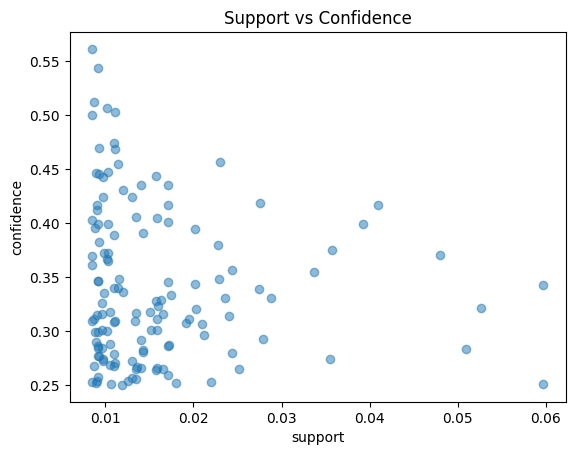

In [11]:
# Plotting the scatter plot of Confidence Vs Support
plt.scatter(assocn_rules_conf['support'], assocn_rules_conf['confidence'], alpha=0.5)
plt.xlabel('support')
plt.ylabel('confidence')
plt.title('Support vs Confidence')
plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


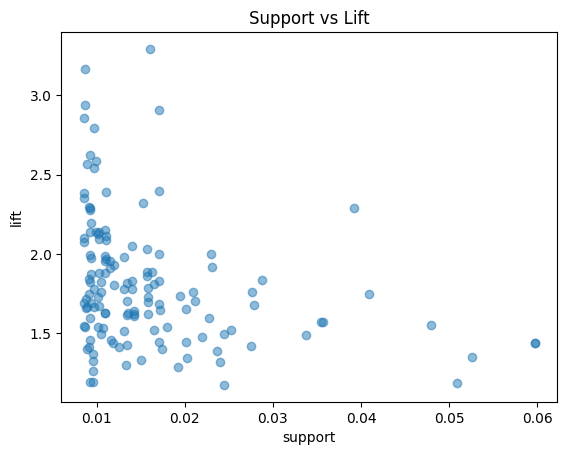

In [12]:
# Plotting the scatter plot of Lift Vs Support
plt.scatter(assocn_rules_conf['support'], assocn_rules_conf['lift'], alpha=0.5)
plt.xlabel('support')
plt.ylabel('lift')
plt.title('Support vs Lift')
plt.show()

In [13]:
# Filter based on lower support, higher confidence, lift, leverage, and conviction
best_rules = assocn_rules_conf[(assocn_rules_conf['confidence'] > 0.4) &
                                (assocn_rules_conf['lift'] > 1.5) &
                                (assocn_rules_conf['support'] > 0.001)]

# Include leverage and conviction for stronger rules
best_rules = best_rules[(best_rules['leverage'] > 0.0025) &
                         (best_rules['conviction'] > 1.1)]

# Display the best rules
best_rules.sort_values(by='confidence', ascending=False)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
83,"(soup, milk)",(mineral water),0.015198,0.238368,0.008532,0.561404,2.355194,1.0,0.004909,1.736520,0.584287,0.034820,0.424136,0.298599
81,"(frozen vegetables, ground beef)",(mineral water),0.016931,0.238368,0.009199,0.543307,2.279277,1.0,0.005163,1.667711,0.570931,0.037378,0.400376,0.290949
70,"(frozen vegetables, ground beef)",(spaghetti),0.016931,0.174110,0.008666,0.511811,2.939582,1.0,0.005718,1.691742,0.671179,0.047515,0.408893,0.280791
75,"(eggs, ground beef)",(mineral water),0.019997,0.238368,0.010132,0.506667,2.125563,1.0,0.005365,1.543848,0.540342,0.040816,0.352268,0.274586
79,"(ground beef, milk)",(mineral water),0.021997,0.238368,0.011065,0.503030,2.110308,1.0,0.005822,1.532552,0.537969,0.044385,0.347493,0.274725
136,"(olive oil, milk)",(mineral water),0.017064,0.238368,0.008532,0.500000,2.097595,1.0,0.004465,1.523264,0.532348,0.034557,0.343515,0.267897
76,"(chocolate, ground beef)",(mineral water),0.023064,0.238368,0.010932,0.473988,1.988472,1.0,0.005434,1.447937,0.508837,0.043640,0.309362,0.259925
125,"(chocolate, pancakes)",(mineral water),0.019864,0.238368,0.009332,0.469799,1.970895,1.0,0.004597,1.436495,0.502600,0.037493,0.303861,0.254474
134,"(frozen vegetables, milk)",(mineral water),0.023597,0.238368,0.011065,0.468927,1.967236,1.0,0.005440,1.434136,0.503555,0.044102,0.302716,0.257674
8,(soup),(mineral water),0.050527,0.238368,0.023064,0.456464,1.914955,1.0,0.011020,1.401255,0.503221,0.086760,0.286354,0.276610


In [14]:
best_rules = assocn_rules_conf[(assocn_rules_conf['confidence'] > 0.5) &
                                (assocn_rules_conf['lift'] > 2) &
                                (assocn_rules_conf['support'] > 0.01)]

best_rules = best_rules[(best_rules['leverage'] > 0.005) &
                         (best_rules['conviction'] > 1)]
best_rules

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
75,"(eggs, ground beef)",(mineral water),0.019997,0.238368,0.010132,0.506667,2.125563,1.0,0.005365,1.543848,0.540342,0.040816,0.352268,0.274586
79,"(ground beef, milk)",(mineral water),0.021997,0.238368,0.011065,0.503030,2.110308,1.0,0.005822,1.532552,0.537969,0.044385,0.347493,0.274725


In [15]:

# Writing the generated rules based on confidence onto a excel file for business use.
w1 = pd.ExcelWriter('Generated_Rules_conf.xlsx')
assocn_rules_conf.to_excel(w1, 'Rules')
w1.close()

# Writing the generated rules based on support onto a excel file for business use.
w2 = pd.ExcelWriter('Generated_Rules_supp.xlsx')
assocn_rules_supp.to_excel(w2, 'Rules')
w2.close()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-15-2b5bba0ba26f>:3: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  assocn_rules_conf.to_excel(w1, 'Rules')
<ipython-input-15-2b5bba0ba26f>:8: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  assocn_rules_supp.to_excel(w2, 'Rules')


**The best association rules are the ones that:**

1. Have a high confidence (indicating reliability)
2. Have a high lift (indicating that the items are strongly related)
3. Have a reasonable support (indicating they are not too rare)



